In [1]:
customer_id,age,income_k,loan_k,years_with_bank,missed_payments,default
C01,23,4.5,1.0,1,0,0
C02,45,12.0,6.0,12,1,0
C03,31,6.0,4.0,5,2,1
C04,26,5.0,2.5,2,0,0
C05,39,9.0,7.5,7,3,1
C06,52,15.0,5.0,18,0,0
C07,29,5.5,3.0,3,1,0
C08,34,7.0,6.5,6,2,1
C09,28,6.5,2.0,4,0,0
C10,41,10.0,8.0,10,4,1


NameError: name 'customer_id' is not defined

# Chapter 1. Why Statistics & Probability matter in ML/DL

In [8]:
import pandas as pd
from io import StringIO

csv = """customer_id,age,income_k,loan_k,years_with_bank,missed_payments,default
C01,23,4.5,1.0,1,0,0
C02,45,12.0,6.0,12,1,0
C03,31,6.0,4.0,5,2,1
C04,26,5.0,2.5,2,0,0
C05,39,9.0,7.5,7,3,1
C06,52,15.0,5.0,18,0,0
C07,29,5.5,3.0,3,1,0
C08,34,7.0,6.5,6,2,1
C09,28,6.5,2.0,4,0,0
C10,41,10.0,8.0,10,4,1
"""
df = pd.read_csv(StringIO(csv))

print(df.head())
print(df.isna().sum())
print(df['default'].value_counts())
print(df.select_dtypes(include=['number']).describe())

  customer_id  age  income_k  loan_k  years_with_bank  missed_payments  \
0         C01   23       4.5     1.0                1                0   
1         C02   45      12.0     6.0               12                1   
2         C03   31       6.0     4.0                5                2   
3         C04   26       5.0     2.5                2                0   
4         C05   39       9.0     7.5                7                3   

   default  
0        0  
1        0  
2        1  
3        0  
4        1  
customer_id        0
age                0
income_k           0
loan_k             0
years_with_bank    0
missed_payments    0
default            0
dtype: int64
default
0    6
1    4
Name: count, dtype: int64
             age   income_k     loan_k  years_with_bank  missed_payments  \
count  10.000000  10.000000  10.000000        10.000000        10.000000   
mean   34.800000   8.050000   4.550000         6.800000         1.300000   
std     9.235198   3.411174   2.420399   

# Chapter 2. Data, variables, and sampling

In [10]:
from sklearn.model_selection import train_test_split

X = df[['age','income_k','loan_k','years_with_bank','missed_payments']]
y = df['default']

# Stratified split keeps default ratio similar in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


default
0    0.571429
1    0.428571
Name: proportion, dtype: float64
default
0    0.666667
1    0.333333
Name: proportion, dtype: float64


# Chapter 3. Exploratory Data Analysis (EDA): your first superpower

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import io
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [13]:
csv_data = """customer_id,age,income_k,loan_k,years_with_bank,missed_payments,default
C01,23,4.5,1.0,1,0,0
C02,45,12.0,6.0,12,1,0
C03,31,6.0,4.0,5,2,1
C04,26,5.0,2.5,2,0,0
C05,39,9.0,7.5,7,3,1
C06,52,15.0,5.0,18,0,0
C07,29,5.5,3.0,3,1,0
C08,34,7.0,6.5,6,2,1
C09,28,6.5,2.0,4,0,0
C10,41,10.0,8.0,10,4,1
"""
# Load data using StringIO from io module
df = pd.read_csv(io.StringIO(csv_data))  # Fixed: using io.StringIO
print("="*60)
print("STEP 1: DATA INSPECTION")
print("="*60)


STEP 1: DATA INSPECTION


In [14]:
# Quick overview
print("\n FIRST LOOK AT DATA:")
print(f"Shape: {df.shape}  (Rows: {df.shape[0]}, Columns: {df.shape[1]})")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nData Types:")
print(df.dtypes)
print(f"\nBasic Info:")
df.info()



 FIRST LOOK AT DATA:
Shape: (10, 7)  (Rows: 10, Columns: 7)

First 5 rows:
  customer_id  age  income_k  loan_k  years_with_bank  missed_payments  \
0         C01   23       4.5     1.0                1                0   
1         C02   45      12.0     6.0               12                1   
2         C03   31       6.0     4.0                5                2   
3         C04   26       5.0     2.5                2                0   
4         C05   39       9.0     7.5                7                3   

   default  
0        0  
1        0  
2        1  
3        0  
4        1  

Data Types:
customer_id         object
age                  int64
income_k           float64
loan_k             float64
years_with_bank      int64
missed_payments      int64
default              int64
dtype: object

Basic Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           ---

In [15]:
print("\n" + "="*60)
print("STEP 2: MISSING VALUES & BASIC STATISTICS")
print("="*60)

# Check for missing values
print("\n MISSING VALUES CHECK:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print(" No missing values found!")
else:
    print("Missing values found:")
    print(missing[missing > 0])

# Basic statistics
print("\n SUMMARY STATISTICS:")
print(df.describe().round(2))



STEP 2: MISSING VALUES & BASIC STATISTICS

 MISSING VALUES CHECK:
 No missing values found!

 SUMMARY STATISTICS:
         age  income_k  loan_k  years_with_bank  missed_payments  default
count  10.00     10.00   10.00            10.00            10.00    10.00
mean   34.80      8.05    4.55             6.80             1.30     0.40
std     9.24      3.41    2.42             5.22             1.42     0.52
min    23.00      4.50    1.00             1.00             0.00     0.00
25%    28.25      5.62    2.62             3.25             0.00     0.00
50%    32.50      6.75    4.50             5.50             1.00     0.00
75%    40.50      9.75    6.38             9.25             2.00     1.00
max    52.00     15.00    8.00            18.00             4.00     1.00



STEP 3: UNIVARIATE ANALYSIS (One Variable at a Time)


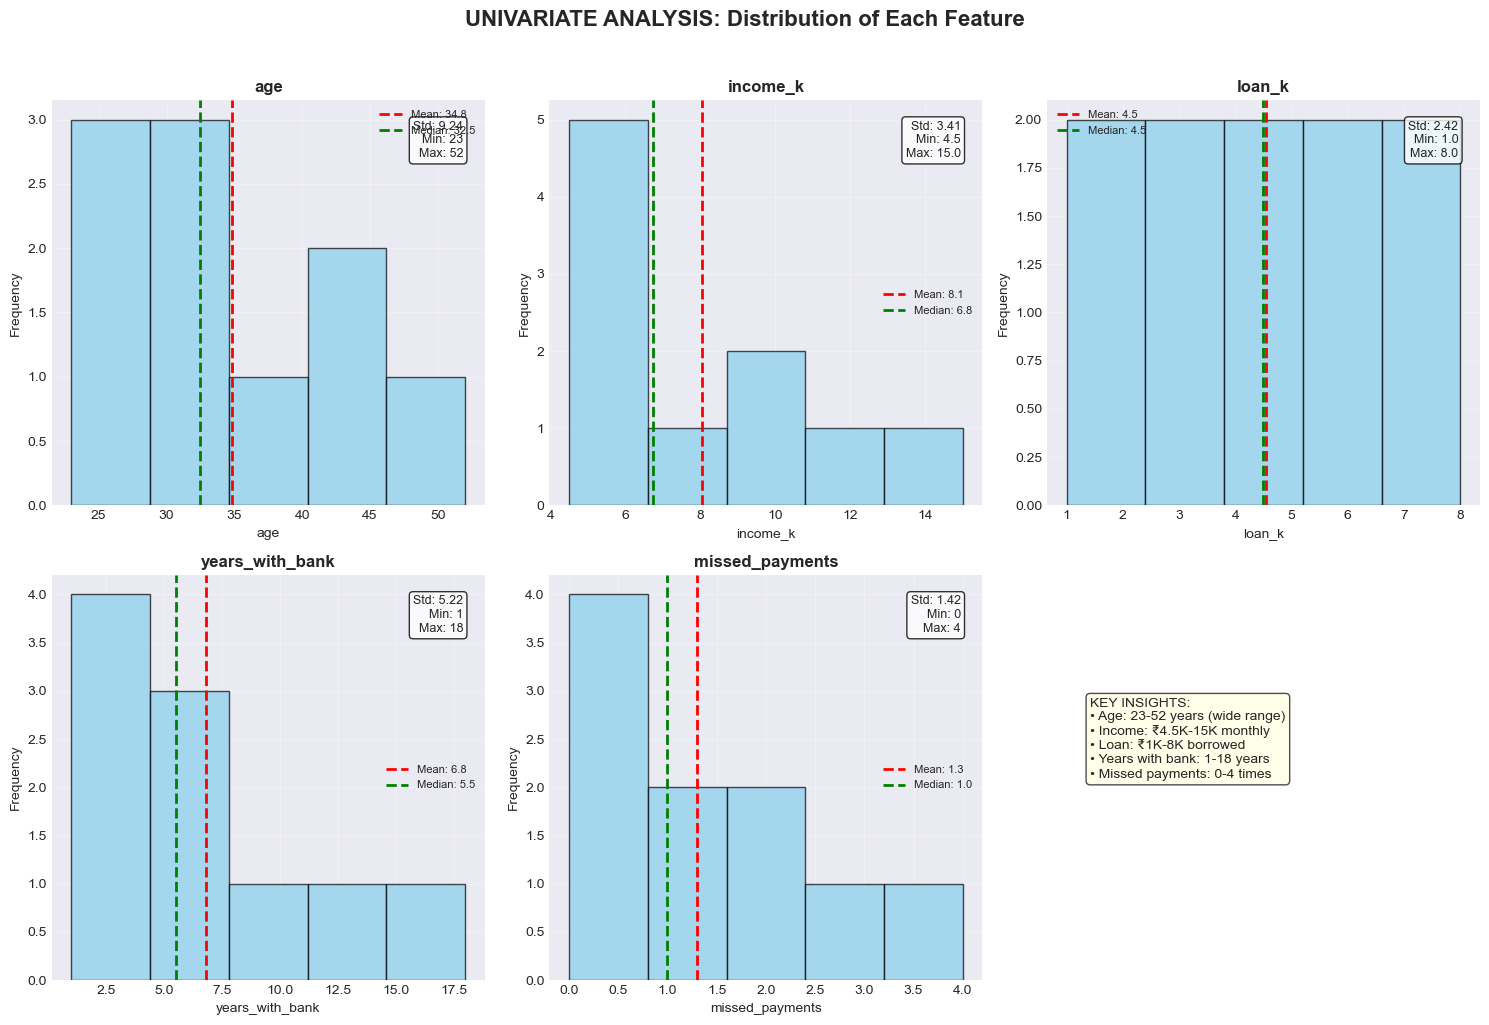

In [16]:
print("\n" + "="*60)
print("STEP 3: UNIVARIATE ANALYSIS (One Variable at a Time)")
print("="*60)

# Select numeric columns for analysis
numeric_cols = ['age', 'income_k', 'loan_k', 'years_with_bank', 'missed_payments']

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('UNIVARIATE ANALYSIS: Distribution of Each Feature', 
             fontsize=16, fontweight='bold', y=1.02)

# Plot histograms and box plots for each numeric column
for idx, col in enumerate(numeric_cols):
    row, col_pos = divmod(idx, 3)
    
    # Histogram
    axes[row, col_pos].hist(df[col], bins=5, alpha=0.7, color='skyblue', edgecolor='black')
    axes[row, col_pos].axvline(df[col].mean(), color='red', linestyle='--', 
                               linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    axes[row, col_pos].axvline(df[col].median(), color='green', linestyle='--', 
                               linewidth=2, label=f'Median: {df[col].median():.1f}')
    axes[row, col_pos].set_title(f'{col}', fontweight='bold')
    axes[row, col_pos].set_xlabel(col)
    axes[row, col_pos].set_ylabel('Frequency')
    axes[row, col_pos].legend(fontsize=8)
    axes[row, col_pos].grid(True, alpha=0.3)
    
    # Add statistics as text
    stats_text = f"Std: {df[col].std():.2f}\nMin: {df[col].min()}\nMax: {df[col].max()}"
    axes[row, col_pos].text(0.95, 0.95, stats_text, transform=axes[row, col_pos].transAxes,
                           fontsize=9, verticalalignment='top', horizontalalignment='right',
                           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Remove empty subplot
axes[1, 2].axis('off')

# Add key insights box
insights_text = """KEY INSIGHTS:
• Age: 23-52 years (wide range)
• Income: ₹4.5K-15K monthly
• Loan: ₹1K-8K borrowed
• Years with bank: 1-18 years
• Missed payments: 0-4 times"""
axes[1, 2].text(0.1, 0.5, insights_text, fontsize=10, 
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.tight_layout()
plt.show()



STEP 4: BIVARIATE ANALYSIS (Relationships Between Variables)


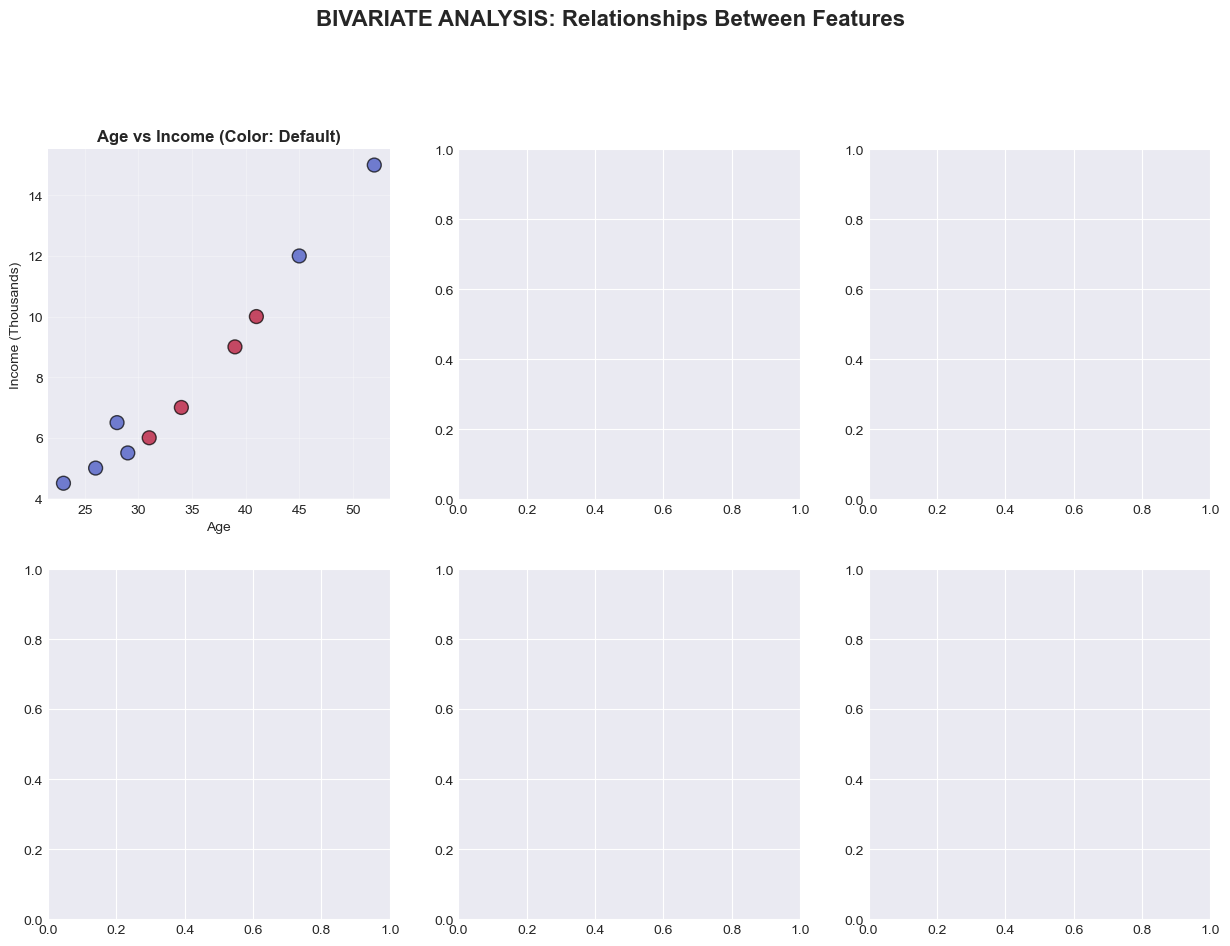

In [17]:
print("\n" + "="*60)
print("STEP 4: BIVARIATE ANALYSIS (Relationships Between Variables)")
print("="*60)

# Create visualization for bivariate analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('BIVARIATE ANALYSIS: Relationships Between Features', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Age vs Income with default status
scatter1 = axes[0, 0].scatter(df['age'], df['income_k'], 
                             c=df['default'], s=100, alpha=0.7, 
                             cmap='coolwarm', edgecolor='black')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Income (Thousands)')
axes[0, 0].set_title('Age vs Income (Color: Default)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)


In [18]:
# Add legend for default
legend_elements = [plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor='blue', markersize=10, label='No Default'),
                   plt.Line2D([0], [0], marker='o', color='w', 
                              markerfacecolor='red', markersize=10, label='Default')]
axes[0, 0].legend(handles=legend_elements)

# 2. Income vs Loan with default status
scatter2 = axes[0, 1].scatter(df['income_k'], df['loan_k'], 
                             c=df['default'], s=100, alpha=0.7, 
                             cmap='coolwarm', edgecolor='black')
axes[0, 1].set_xlabel('Income (Thousands)')
axes[0, 1].set_ylabel('Loan (Thousands)')
axes[0, 1].set_title('Income vs Loan (Color: Default)', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)


In [19]:
# Add 45-degree line (loan = income)
max_val = max(df['income_k'].max(), df['loan_k'].max())
axes[0, 1].plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Loan = Income')
axes[0, 1].legend()

# 3. Years with bank vs Missed payments
scatter3 = axes[0, 2].scatter(df['years_with_bank'], df['missed_payments'], 
                             c=df['default'], s=100, alpha=0.7, 
                             cmap='coolwarm', edgecolor='black')
axes[0, 2].set_xlabel('Years with Bank')
axes[0, 2].set_ylabel('Missed Payments')
axes[0, 2].set_title('Loyalty vs Payment Issues', fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)


In [20]:
# 4. Correlation Heatmap
axes[1, 0].axis('off')  # We'll use this for text
corr_matrix = df[numeric_cols + ['default']].corr()

# Create heatmap in separate subplot
im = axes[1, 1].imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[1, 1].set_title('Correlation Heatmap', fontweight='bold')
axes[1, 1].set_xticks(range(len(corr_matrix.columns)))
axes[1, 1].set_yticks(range(len(corr_matrix.columns)))
axes[1, 1].set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
axes[1, 1].set_yticklabels(corr_matrix.columns)

# Add correlation values
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        text = axes[1, 1].text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                               ha="center", va="center", color="black", fontsize=9)



STEP 4: BIVARIATE ANALYSIS (Relationships Between Variables)


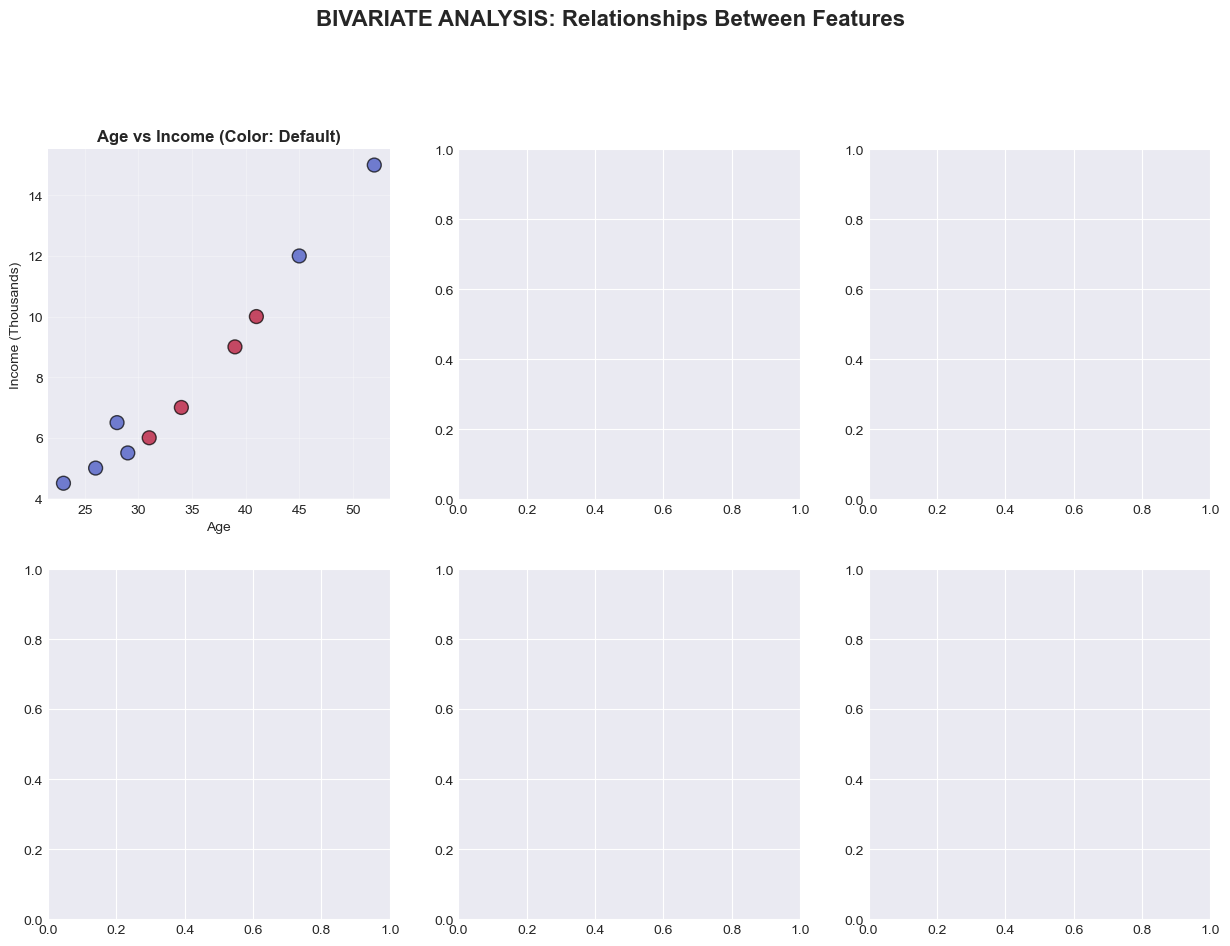

In [21]:
print("\n" + "="*60)
print("STEP 4: BIVARIATE ANALYSIS (Relationships Between Variables)")
print("="*60)

# Create visualization for bivariate analysis
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('BIVARIATE ANALYSIS: Relationships Between Features', 
             fontsize=16, fontweight='bold', y=1.02)

# 1. Age vs Income with default status
scatter1 = axes[0, 0].scatter(df['age'], df['income_k'], 
                             c=df['default'], s=100, alpha=0.7, 
                             cmap='coolwarm', edgecolor='black')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Income (Thousands)')
axes[0, 0].set_title('Age vs Income (Color: Default)', fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)


STEP 5: TARGET VARIABLE ANALYSIS (Default Prediction)


C:\Users\Admin\AppData\Local\Temp\ipykernel_8468\2804527943.py:28: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  default_by_income = df.groupby('income_group')['default'].mean() * 100


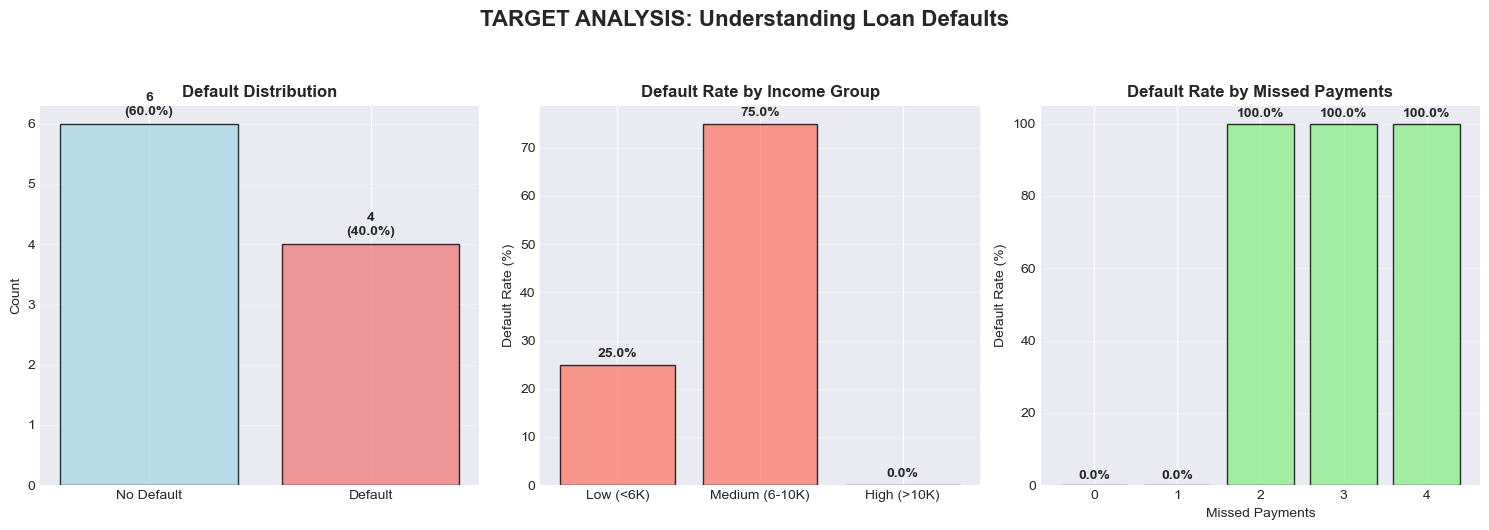


 TARGET VARIABLE STATISTICS:
Default Rate: 40.0%
Non-default: 6 customers
Default: 4 customers


In [22]:
print("\n" + "="*60)
print("STEP 5: TARGET VARIABLE ANALYSIS (Default Prediction)")
print("="*60)

# Create visualization for target analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('TARGET ANALYSIS: Understanding Loan Defaults', 
             fontsize=16, fontweight='bold', y=1.05)

# 1. Default distribution
default_counts = df['default'].value_counts()
colors = ['lightblue', 'lightcoral']
axes[0].bar(['No Default', 'Default'], default_counts.values, 
           color=colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Default Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')

# Add percentages on bars
for i, (label, value) in enumerate(default_counts.items()):
    percentage = (value / len(df)) * 100
    axes[0].text(i, value + 0.1, f'{value}\n({percentage:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

# 2. Default by income groups
df['income_group'] = pd.cut(df['income_k'], bins=[0, 6, 10, 20], 
                           labels=['Low (<6K)', 'Medium (6-10K)', 'High (>10K)'])
default_by_income = df.groupby('income_group')['default'].mean() * 100

axes[1].bar(default_by_income.index, default_by_income.values, 
           color='salmon', edgecolor='black', alpha=0.8)
axes[1].set_title('Default Rate by Income Group', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].grid(True, alpha=0.3, axis='y')

# Add values on bars
for i, value in enumerate(default_by_income.values):
    axes[1].text(i, value + 1, f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

# 3. Default by missed payments
default_by_missed = df.groupby('missed_payments')['default'].mean() * 100

axes[2].bar([str(x) for x in default_by_missed.index], default_by_missed.values, 
           color='lightgreen', edgecolor='black', alpha=0.8)
axes[2].set_title('Default Rate by Missed Payments', fontweight='bold')
axes[2].set_xlabel('Missed Payments')
axes[2].set_ylabel('Default Rate (%)')
axes[2].grid(True, alpha=0.3, axis='y')

# Add values on bars
for i, value in enumerate(default_by_missed.values):
    axes[2].text(i, value + 1, f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print target statistics
print("\n TARGET VARIABLE STATISTICS:")
print(f"Default Rate: {(df['default'].mean() * 100):.1f}%")
print(f"Non-default: {default_counts.get(0, 0)} customers")
print(f"Default: {default_counts.get(1, 0)} customers")


# Chapter 4. Box plots, outliers, and robust thinking

In [24]:
# Demonstrate standard vs robust scaling
from sklearn.preprocessing import StandardScaler, RobustScaler
import numpy as np

loan = df[['loan_k']].values
std_scaled = StandardScaler().fit_transform(loan)
rob_scaled = RobustScaler().fit_transform(loan)

print("Original loan_k:", loan.ravel())
print("StandardScaler:", np.round(std_scaled.ravel(), 2))
print("RobustScaler:", np.round(rob_scaled.ravel(), 2))


Original loan_k: [1.  6.  4.  2.5 7.5 5.  3.  6.5 2.  8. ]
StandardScaler: [-1.55  0.63 -0.24 -0.89  1.28  0.2  -0.68  0.85 -1.11  1.5 ]
RobustScaler: [-0.93  0.4  -0.13 -0.53  0.8   0.13 -0.4   0.53 -0.67  0.93]


# Chapter 5. Central tendency and dispersion (mean, median, variance, SD)

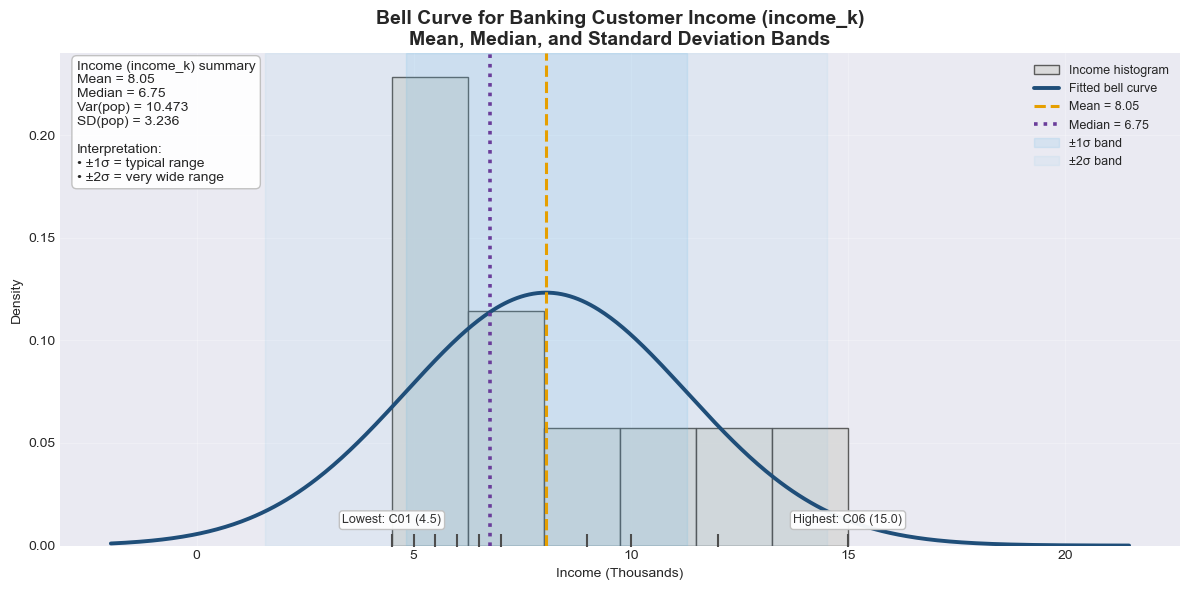

'/mnt/data/bell_curve_income_k_v2.png'

In [26]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data
csv_data = """customer_id,age,income_k,loan_k,years_with_bank,missed_payments,default
C01,23,4.5,1.0,1,0,0
C02,45,12.0,6.0,12,1,0
C03,31,6.0,4.0,5,2,1
C04,26,5.0,2.5,2,0,0
C05,39,9.0,7.5,7,3,1
C06,52,15.0,5.0,18,0,0
C07,29,5.5,3.0,3,1,0
C08,34,7.0,6.5,6,2,1
C09,28,6.5,2.0,4,0,0
C10,41,10.0,8.0,10,4,1
"""
df = pd.read_csv(io.StringIO(csv_data))

# Stats (population variance & SD)
x = df["income_k"].to_numpy()
mean = np.mean(x)
median = np.median(x)
var_pop = np.mean((x - mean) ** 2)
sd_pop = np.sqrt(var_pop)

# Normal PDF
xmin = x.min() - 2 * sd_pop
xmax = x.max() + 2 * sd_pop
xs = np.linspace(xmin, xmax, 500)
pdf = (1 / (sd_pop * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mean) / sd_pop) ** 2)

# Plot (improved, print-friendly colors)
plt.figure(figsize=(12, 6))

# Histogram (neutral)
plt.hist(
    x, bins=6, density=True,
    color="#D9D9D9", edgecolor="#4D4D4D", linewidth=1.0,
    alpha=0.9, label="Income histogram"
)

# Bell curve (navy)
plt.plot(xs, pdf, linewidth=2.8, color="#1F4E79", label="Fitted bell curve")

# Mean & Median (distinct, readable)
plt.axvline(mean, linestyle="--", linewidth=2.2, color="#E69F00", label=f"Mean = {mean:.2f}")
plt.axvline(median, linestyle=":", linewidth=2.6, color="#6A3D9A", label=f"Median = {median:.2f}")

# SD bands (subtle)
plt.axvspan(mean - sd_pop, mean + sd_pop, color="#56B4E9", alpha=0.14, label="±1σ band")
plt.axvspan(mean - 2*sd_pop, mean + 2*sd_pop, color="#56B4E9", alpha=0.07, label="±2σ band")

# Rug: each customer income (dark gray)
y0 = 0.0
plt.scatter(x, np.full_like(x, y0), marker="|", s=320, color="#4D4D4D", zorder=5)

# Annotate lowest & highest incomes with small callouts
low_idx = int(np.argmin(x))
high_idx = int(np.argmax(x))
plt.annotate(
    f"Lowest: {df.loc[low_idx,'customer_id']} ({x[low_idx]:.1f})",
    (x[low_idx], y0), textcoords="offset points", xytext=(0, 16), ha="center",
    fontsize=9, color="#333333",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BFBFBF", alpha=0.95)
)
plt.annotate(
    f"Highest: {df.loc[high_idx,'customer_id']} ({x[high_idx]:.1f})",
    (x[high_idx], y0), textcoords="offset points", xytext=(0, 16), ha="center",
    fontsize=9, color="#333333",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="#BFBFBF", alpha=0.95)
)

# Info box (clean white card)
info = (
    "Income (income_k) summary\n"
    f"Mean = {mean:.2f}\n"
    f"Median = {median:.2f}\n"
    f"Var(pop) = {var_pop:.3f}\n"
    f"SD(pop) = {sd_pop:.3f}\n\n"
    "Interpretation:\n"
    "• ±1σ = typical range\n"
    "• ±2σ = very wide range"
)
plt.gca().text(
    0.015, 0.985, info,
    transform=plt.gca().transAxes, va="top", ha="left", fontsize=10,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="white", edgecolor="#BFBFBF", alpha=0.95)
)

plt.title("Bell Curve for Banking Customer Income (income_k)\nMean, Median, and Standard Deviation Bands",
          fontsize=14, fontweight="bold")
plt.xlabel("Income (Thousands)")
plt.ylabel("Density")
plt.grid(True, alpha=0.25)

# Trim legend items (avoid too much clutter)
handles, labels = plt.gca().get_legend_handles_labels()
# Keep first 5 entries in a sensible order
keep = ["Income histogram", "Fitted bell curve", f"Mean = {mean:.2f}", f"Median = {median:.2f}", "±1σ band", "±2σ band"]
kept_handles, kept_labels = [], []
for h, l in zip(handles, labels):
    if l in keep and l not in kept_labels:
        kept_handles.append(h); kept_labels.append(l)
plt.legend(kept_handles, kept_labels, loc="upper right", fontsize=9, framealpha=0.95)

plt.tight_layout()

out_path = "/mnt/data/bell_curve_income_k_v2.png"
plt.savefig(out_path, dpi=220)
plt.show()
out_path


# Chapter 6. Distributions: Normal, z-score, and standardization

In [29]:
import io
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Z-score for income_k (manual)
income = df['income_k']
z = (income - income.mean()) / income.std(ddof=0)  # population SD
print(pd.DataFrame({'income_k': income, 'z_income': z.round(2)}))
# StandardScaler in a pipeline
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression())
])

pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print(classification_report(y_test, pred))

   income_k  z_income
0       4.5     -1.10
1      12.0      1.22
2       6.0     -0.63
3       5.0     -0.94
4       9.0      0.29
5      15.0      2.15
6       5.5     -0.79
7       7.0     -0.32
8       6.5     -0.48
9      10.0      0.60
              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       0.00      0.00      0.00         1

    accuracy                           0.67         3
   macro avg       0.33      0.50      0.40         3
weighted avg       0.44      0.67      0.53         3



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Chapter 7. Probability basics: events, conditional probability, independence

In [31]:
# Simple conditional probability example using counts
# Suppose among 100 customers: 30 are high-loan, 20 are default, and 12 are both.
P_B = 30/100               # P(high-loan)
P_A_and_B = 12/100         # P(default AND high-loan)
P_A_given_B = P_A_and_B / P_B
print("P(default | high-loan) =", P_A_given_B)


P(default | high-loan) = 0.4


# Chapter 8. Bayes’ theorem and Naive Bayes intuition

In [32]:
# Tiny Bayes example
# Prior: P(default)=0.20
# Likelihood: P(missed>=2 | default)=0.60
# Evidence: P(missed>=2)=0.25
P_default = 0.20
P_e_given_default = 0.60
P_e = 0.25
P_default_given_e = (P_e_given_default * P_default) / P_e
print("P(default | missed>=2) =", P_default_given_e)


P(default | missed>=2) = 0.48


# Chapter 9. Binomial and Poisson: counting-world distributions

In [33]:
import math
def nCr(n, r):
    return math.factorial(n) // (math.factorial(r) * math.factorial(n-r))

# Binomial P(X=2) for n=5, p=0.5
n, p, x = 5, 0.5, 2
P = nCr(n,x) * (p**x) * ((1-p)**(n-x))
print("Binomial P(X=2) =", P)

# Poisson P(X=3) for lambda=2
lam, k = 2, 3
Pp = (lam**k) * math.exp(-lam) / math.factorial(k)
print("Poisson P(X=3) =", Pp)


Binomial P(X=2) = 0.3125
Poisson P(X=3) = 0.1804470443154836


# Chapter 10. Estimation and confidence intervals (CI)

In [34]:
# Simple CI for a mean when sigma is known (z-based)
# Example: mean=41100, sigma=4500, n=36, 95% CI -> z=1.96
xbar, sigma, n, z = 41100, 4500, 36, 1.96
se = sigma / (n**0.5)
lower = xbar - z*se
upper = xbar + z*se
print("95% CI:", (round(lower,2), round(upper,2)))
# Bootstrap CI for model accuracy (concept)
# 1) sample test set with replacement many times
# 2) compute accuracy each time
# 3) take 2.5 and 97.5 percentiles as 95% CI


95% CI: (39630.0, 42570.0)


# Chapter 12. Correlation, covariance, and the road to linear regression

In [35]:
# Correlation matrix for numeric features
corr = df[['age','income_k','loan_k','years_with_bank','missed_payments','default']].corr(numeric_only=True)
print(corr.round(2))
# Very important: correlation != causation
# Example: Ice cream sales and drowning both increase in summer.


                  age  income_k  loan_k  years_with_bank  missed_payments  \
age              1.00      0.98    0.71             0.98             0.28   
income_k         0.98      1.00    0.60             0.99             0.13   
loan_k           0.71      0.60    1.00             0.59             0.82   
years_with_bank  0.98      0.99    0.59             1.00             0.14   
missed_payments  0.28      0.13    0.82             0.14             1.00   
default          0.14     -0.01    0.69             0.03             0.88   

                 default  
age                 0.14  
income_k           -0.01  
loan_k              0.69  
years_with_bank     0.03  
missed_payments     0.88  
default             1.00  


# Chapter 13. ANOVA and when many groups are involved

In [36]:
# Practical note:
# In ML, you often use ANOVA F-test for feature selection:
# sklearn.feature_selection.f_classif or f_regression
from sklearn.feature_selection import f_classif
import numpy as np

X = df[['age','income_k','loan_k','years_with_bank','missed_payments']].to_numpy()
y = df['default'].to_numpy()
F, p = f_classif(X, y)
print("F:", np.round(F,3))
print("p:", np.round(p,4))


F: [1.4900e-01 1.0000e-03 7.4080e+00 9.0000e-03 2.7461e+01]
p: [7.097e-01 9.724e-01 2.620e-02 9.280e-01 8.000e-04]


# Chapter 14. Common mistakes in ML statistics (leakage, bias, overconfidence)

In [37]:
# Golden rule: fit transforms only on training data
# Wrong:
# scaler.fit_transform(full_data)

# Right:
# scaler.fit(X_train)
# X_train_scaled = scaler.transform(X_train)
# X_test_scaled  = scaler.transform(X_test)
